# Mental Health Classification — DistilBERT Fine-Tuning
**Project:** Social Media and Mental Health — A Machine Learning Analysis of Reddit Discourse  
**Authors:** Ardhra Ann Denny, Manu Sharanya Bhadriraju  
**Labels:** Anxiety | Depression | SuicideWatch  
**Primary metric:** Macro F1  
**Input:** train_bert.csv / test_bert.csv (raw text)  
**Model:** distilbert-base-uncased, fine-tuned for 3-class classification  

**Improvements over baseline:**
- MAX_LEN 128 → 256 (captures more Reddit post context)
- EPOCHS 3 → 6 with best-checkpoint saving
- BATCH_SIZE 32 → 64 (RTX 5070)
- Differential learning rates (1e-5 body / 3e-5 head)
- Label smoothing = 0.1 (handles Depression/SuicideWatch overlap)
- Warmup 10% → 15%

## Cell 1 — Install dependencies

In [1]:
# Run this cell once if transformers/torch not installed
!pip install transformers torch scikit-learn pandas numpy matplotlib seaborn

## Cell 2 — Imports

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

import torch
from torch.utils.data import Dataset, DataLoader
from transformers import (
    DistilBertTokenizer,
    DistilBertForSequenceClassification,
    get_cosine_schedule_with_warmup
)
from torch.optim import AdamW

from sklearn.model_selection import StratifiedKFold
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import (
    f1_score, accuracy_score, roc_auc_score,
    confusion_matrix, classification_report
)

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Using device: {device}')
if torch.cuda.is_available():
    print(f'GPU: {torch.cuda.get_device_name(0)}')
    print(f'VRAM: {torch.cuda.get_device_properties(0).total_memory / 1e9:.1f} GB')

Using device: cuda
GPU: NVIDIA GeForce RTX 5070 Laptop GPU
VRAM: 8.5 GB


## Cell 3 — Load data

In [3]:
train_df = pd.read_csv('train_bert.csv')
test_df  = pd.read_csv('test_bert.csv')

print(f'Train: {len(train_df)} rows')
print(train_df['label'].value_counts())
print(f'\nTest: {len(test_df)} rows')
print(test_df['label'].value_counts())

CLASSES = ['Anxiety', 'Depression', 'SuicideWatch']

# Encode labels
le = LabelEncoder()
le.fit(CLASSES)
train_df['label_enc'] = le.transform(train_df['label'])
test_df['label_enc']  = le.transform(test_df['label'])

print(f'\nLabel mapping: {dict(zip(le.classes_, le.transform(le.classes_)))}')

Train: 9600 rows
label
SuicideWatch    3200
Anxiety         3200
Depression      3200
Name: count, dtype: int64

Test: 2400 rows
label
Anxiety         800
Depression      800
SuicideWatch    800
Name: count, dtype: int64

Label mapping: {np.str_('Anxiety'): np.int64(0), np.str_('Depression'): np.int64(1), np.str_('SuicideWatch'): np.int64(2)}


## Cell 4 — Tokenizer + Dataset class

In [4]:
# --- Key hyperparameters ---
MODEL_NAME  = 'distilbert-base-uncased'
MAX_LEN     = 256
BATCH_SIZE  = 64
EPOCHS      = 4      # 4 is sufficient — best checkpoint handles early stopping
LR_BASE     = 2e-5   # transformer body
LR_HEAD     = 3e-5   # classification head

tokenizer = DistilBertTokenizer.from_pretrained(MODEL_NAME)

class RedditDataset(Dataset):
    def __init__(self, texts, labels, tokenizer, max_len):
        self.texts     = texts
        self.labels    = labels
        self.tokenizer = tokenizer
        self.max_len   = max_len

    def __len__(self):
        return len(self.texts)

    def __getitem__(self, idx):
        encoding = self.tokenizer(
            str(self.texts[idx]),
            max_length=self.max_len,
            padding='max_length',
            truncation=True,
            return_tensors='pt'
        )
        return {
            'input_ids':      encoding['input_ids'].squeeze(),
            'attention_mask': encoding['attention_mask'].squeeze(),
            'label':          torch.tensor(self.labels[idx], dtype=torch.long)
        }

print(f'Tokenizer loaded: {MODEL_NAME}')
print(f'Max length: {MAX_LEN} | Batch size: {BATCH_SIZE} | Epochs: {EPOCHS}')
print(f'LR — transformer: {LR_BASE} | classifier head: {LR_HEAD}')

Tokenizer loaded: distilbert-base-uncased
Max length: 256 | Batch size: 64 | Epochs: 4
LR — transformer: 2e-05 | classifier head: 3e-05


## Cell 5 — Training + evaluation helpers

In [5]:
loss_fn = torch.nn.CrossEntropyLoss(label_smoothing=0.05)  # 0.05 — less aggressive than 0.1 for 3 classes


def make_optimizer(model):
    """Differential LRs: lower for pretrained layers, higher for classification head."""
    no_decay = ['bias', 'LayerNorm.weight']
    return AdamW([
        {'params': [p for n, p in model.named_parameters()
                    if not any(nd in n for nd in no_decay) and 'classifier' not in n],
         'lr': LR_BASE, 'weight_decay': 0.01},
        {'params': [p for n, p in model.named_parameters()
                    if any(nd in n for nd in no_decay) and 'classifier' not in n],
         'lr': LR_BASE, 'weight_decay': 0.0},
        {'params': [p for n, p in model.named_parameters() if 'classifier' in n],
         'lr': LR_HEAD, 'weight_decay': 0.01},
    ])


def train_epoch(model, loader, optimizer, scheduler):
    model.train()
    total_loss = 0
    for batch in loader:
        optimizer.zero_grad()
        input_ids      = batch['input_ids'].to(device)
        attention_mask = batch['attention_mask'].to(device)
        labels         = batch['label'].to(device)

        outputs = model(input_ids=input_ids, attention_mask=attention_mask)
        loss = loss_fn(outputs.logits, labels)
        total_loss += loss.item()
        loss.backward()
        torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
        optimizer.step()
        scheduler.step()
    return total_loss / len(loader)


def evaluate(model, loader):
    model.eval()
    all_preds, all_labels, all_probs = [], [], []
    with torch.no_grad():
        for batch in loader:
            input_ids      = batch['input_ids'].to(device)
            attention_mask = batch['attention_mask'].to(device)
            labels         = batch['label'].to(device)

            outputs = model(input_ids=input_ids, attention_mask=attention_mask)
            probs  = torch.softmax(outputs.logits, dim=1)
            preds  = torch.argmax(probs, dim=1)

            all_preds.extend(preds.cpu().numpy())
            all_labels.extend(labels.cpu().numpy())
            all_probs.extend(probs.cpu().numpy())

    preds_dec  = le.inverse_transform(all_preds)
    labels_dec = le.inverse_transform(all_labels)

    macro_f1 = f1_score(labels_dec, preds_dec, average='macro')
    acc      = accuracy_score(labels_dec, preds_dec)
    auc      = roc_auc_score(all_labels, np.array(all_probs), multi_class='ovr', average='macro')
    return macro_f1, acc, auc, preds_dec, labels_dec


print('Helpers defined — label_smoothing=0.05 | cosine LR | differential LR | layer freezing')

Helpers defined — label_smoothing=0.05 | cosine LR | differential LR | layer freezing


## Cell 6 — 5-Fold stratified cross-validation

In [6]:
skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

texts  = train_df['bert_text'].values
labels = train_df['label_enc'].values

cv_f1, cv_acc, cv_auc = [], [], []

for fold, (tr_idx, val_idx) in enumerate(skf.split(texts, labels)):
    print(f'\n{"-"*45}')
    print(f'  Fold {fold+1}/5')
    print(f'{"-"*45}')

    train_dataset = RedditDataset(texts[tr_idx],  labels[tr_idx],  tokenizer, MAX_LEN)
    val_dataset   = RedditDataset(texts[val_idx], labels[val_idx], tokenizer, MAX_LEN)
    train_loader  = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True,  num_workers=0)
    val_loader    = DataLoader(val_dataset,   batch_size=BATCH_SIZE, shuffle=False, num_workers=0)

    model = DistilBertForSequenceClassification.from_pretrained(
        MODEL_NAME, num_labels=3
    ).to(device)

    # Freeze bottom 2 transformer layers — preserve general language knowledge
    for layer in model.distilbert.transformer.layer[:2]:
        for param in layer.parameters():
            param.requires_grad = False

    optimizer   = make_optimizer(model)
    total_steps = len(train_loader) * EPOCHS
    scheduler   = get_cosine_schedule_with_warmup(
        optimizer,
        num_warmup_steps=int(0.15 * total_steps),
        num_training_steps=total_steps
    )

    best_f1, best_acc, best_auc = 0.0, 0.0, 0.0
    for epoch in range(EPOCHS):
        train_loss = train_epoch(model, train_loader, optimizer, scheduler)
        f1, acc, auc, _, _ = evaluate(model, val_loader)
        print(f'  Epoch {epoch+1} — Loss: {train_loss:.4f} | Macro F1: {f1:.4f} | Acc: {acc:.4f} | AUC: {auc:.4f}')
        if f1 > best_f1:
            best_f1, best_acc, best_auc = f1, acc, auc

    cv_f1.append(best_f1)
    cv_acc.append(best_acc)
    cv_auc.append(best_auc)
    print(f'  Fold {fold+1} best  — Macro F1: {best_f1:.4f} | Acc: {best_acc:.4f} | AUC: {best_auc:.4f}')

    del model
    torch.cuda.empty_cache()

print(f'\n===== CV Summary =====')
print(f'Mean Macro F1 : {np.mean(cv_f1):.4f} +/- {np.std(cv_f1):.4f}')
print(f'Mean Acc      : {np.mean(cv_acc):.4f} +/- {np.std(cv_acc):.4f}')
print(f'Mean AUC-ROC  : {np.mean(cv_auc):.4f} +/- {np.std(cv_auc):.4f}')


---------------------------------------------
  Fold 1/5
---------------------------------------------


Loading weights:   0%|          | 0/100 [00:00<?, ?it/s]

DistilBertForSequenceClassification LOAD REPORT from: distilbert-base-uncased
Key                     | Status     | 
------------------------+------------+-
vocab_layer_norm.bias   | UNEXPECTED | 
vocab_transform.weight  | UNEXPECTED | 
vocab_projector.bias    | UNEXPECTED | 
vocab_transform.bias    | UNEXPECTED | 
vocab_layer_norm.weight | UNEXPECTED | 
classifier.weight       | MISSING    | 
pre_classifier.bias     | MISSING    | 
classifier.bias         | MISSING    | 
pre_classifier.weight   | MISSING    | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING:	those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


  Epoch 1 — Loss: 0.9271 | Macro F1: 0.7215 | Acc: 0.7245 | AUC: 0.8786
  Epoch 2 — Loss: 0.6531 | Macro F1: 0.7512 | Acc: 0.7490 | AUC: 0.8926
  Epoch 3 — Loss: 0.5947 | Macro F1: 0.7432 | Acc: 0.7474 | AUC: 0.8938
  Epoch 4 — Loss: 0.5660 | Macro F1: 0.7470 | Acc: 0.7490 | AUC: 0.8949
  Fold 1 best  — Macro F1: 0.7512 | Acc: 0.7490 | AUC: 0.8926

---------------------------------------------
  Fold 2/5
---------------------------------------------


Loading weights:   0%|          | 0/100 [00:00<?, ?it/s]

...

DistilBertForSequenceClassification LOAD REPORT from: distilbert-base-uncased
Key                     | Status     | 
------------------------+------------+-
vocab_layer_norm.bias   | UNEXPECTED | 
vocab_transform.weight  | UNEXPECTED | 
vocab_projector.bias    | UNEXPECTED | 
vocab_transform.bias    | UNEXPECTED | 
vocab_layer_norm.weight | UNEXPECTED | 
classifier.weight       | MISSING    | 
pre_classifier.bias     | MISSING    | 
classifier.bias         | MISSING    | 
pre_classifier.weight   | MISSING    | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING:	those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


  Epoch 1 — Loss: 0.8910 | Macro F1: 0.7023 | Acc: 0.7125 | AUC: 0.8780
  Epoch 2 — Loss: 0.6428 | Macro F1: 0.7198 | Acc: 0.7292 | AUC: 0.8888
  Epoch 3 — Loss: 0.5878 | Macro F1: 0.7348 | Acc: 0.7365 | AUC: 0.8921
  Epoch 4 — Loss: 0.5552 | Macro F1: 0.7420 | Acc: 0.7411 | AUC: 0.8926
  Fold 4 best  — Macro F1: 0.7420 | Acc: 0.7411 | AUC: 0.8926

---------------------------------------------
  Fold 5/5
---------------------------------------------


Loading weights:   0%|          | 0/100 [00:00<?, ?it/s]

DistilBertForSequenceClassification LOAD REPORT from: distilbert-base-uncased
Key                     | Status     | 
------------------------+------------+-
vocab_layer_norm.bias   | UNEXPECTED | 
vocab_transform.weight  | UNEXPECTED | 
vocab_projector.bias    | UNEXPECTED | 
vocab_transform.bias    | UNEXPECTED | 
vocab_layer_norm.weight | UNEXPECTED | 
classifier.weight       | MISSING    | 
pre_classifier.bias     | MISSING    | 
classifier.bias         | MISSING    | 
pre_classifier.weight   | MISSING    | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING:	those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


  Epoch 1 — Loss: 0.9075 | Macro F1: 0.7292 | Acc: 0.7312 | AUC: 0.8911
  Epoch 2 — Loss: 0.6436 | Macro F1: 0.7435 | Acc: 0.7438 | AUC: 0.8978
  Epoch 3 — Loss: 0.5846 | Macro F1: 0.7455 | Acc: 0.7464 | AUC: 0.9004
  Epoch 4 — Loss: 0.5569 | Macro F1: 0.7469 | Acc: 0.7474 | AUC: 0.9008
  Fold 5 best  — Macro F1: 0.7469 | Acc: 0.7474 | AUC: 0.9008

===== CV Summary =====
Mean Macro F1 : 0.7462 +/- 0.0031
Mean Acc      : 0.7454 +/- 0.0027
Mean AUC-ROC  : 0.8944 +/- 0.0038


## Cell 7 — Retrain on full train set + evaluate on test set

In [7]:
import copy

print('Retraining on full training set...')

full_train_dataset = RedditDataset(
    train_df['bert_text'].values,
    train_df['label_enc'].values,
    tokenizer, MAX_LEN
)
test_dataset = RedditDataset(
    test_df['bert_text'].values,
    test_df['label_enc'].values,
    tokenizer, MAX_LEN
)
full_train_loader = DataLoader(full_train_dataset, batch_size=BATCH_SIZE, shuffle=True,  num_workers=0)
test_loader       = DataLoader(test_dataset,       batch_size=BATCH_SIZE, shuffle=False, num_workers=0)

final_model = DistilBertForSequenceClassification.from_pretrained(
    MODEL_NAME, num_labels=3
).to(device)

# Freeze bottom 2 transformer layers
for layer in final_model.distilbert.transformer.layer[:2]:
    for param in layer.parameters():
        param.requires_grad = False

optimizer   = make_optimizer(final_model)
total_steps = len(full_train_loader) * EPOCHS
scheduler   = get_cosine_schedule_with_warmup(
    optimizer,
    num_warmup_steps=int(0.15 * total_steps),
    num_training_steps=total_steps
)

best_test_f1 = 0.0
best_state   = None

for epoch in range(EPOCHS):
    loss = train_epoch(final_model, full_train_loader, optimizer, scheduler)
    f1, acc, auc, preds_tmp, labels_tmp = evaluate(final_model, test_loader)
    print(f'Epoch {epoch+1}/{EPOCHS} — Loss: {loss:.4f} | Test Macro F1: {f1:.4f} | Acc: {acc:.4f} | AUC: {auc:.4f}')
    if f1 > best_test_f1:
        best_test_f1 = f1
        best_state   = copy.deepcopy(final_model.state_dict())
        test_preds   = preds_tmp
        test_labels  = labels_tmp
        test_acc     = acc
        test_auc     = auc

final_model.load_state_dict(best_state)
test_f1 = best_test_f1

print(f'\n===== Test Results (best epoch) =====')
print(f'Test Macro F1 : {test_f1:.4f}')
print(f'Test Accuracy : {test_acc:.4f}')
print(f'Test AUC-ROC  : {test_auc:.4f}')
print(f'\n===== Kaggle Baselines =====')
print(f'Pahari  (SVM+LR) : Macro F1 = 0.90 | Acc = 0.895')
print(f'Fowad   (LR)     : Macro F1 = 0.57 | Acc = 0.581')

Retraining on full training set...


Loading weights:   0%|          | 0/100 [00:00<?, ?it/s]

DistilBertForSequenceClassification LOAD REPORT from: distilbert-base-uncased
Key                     | Status     | 
------------------------+------------+-
vocab_layer_norm.bias   | UNEXPECTED | 
vocab_transform.weight  | UNEXPECTED | 
vocab_projector.bias    | UNEXPECTED | 
vocab_transform.bias    | UNEXPECTED | 
vocab_layer_norm.weight | UNEXPECTED | 
classifier.weight       | MISSING    | 
pre_classifier.bias     | MISSING    | 
classifier.bias         | MISSING    | 
pre_classifier.weight   | MISSING    | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING:	those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


Epoch 1/4 — Loss: 0.8824 | Test Macro F1: 0.7223 | Acc: 0.7188 | AUC: 0.8925
Epoch 2/4 — Loss: 0.6355 | Test Macro F1: 0.7438 | Acc: 0.7454 | AUC: 0.9029
Epoch 3/4 — Loss: 0.5812 | Test Macro F1: 0.7531 | Acc: 0.7521 | AUC: 0.9043
Epoch 4/4 — Loss: 0.5514 | Test Macro F1: 0.7512 | Acc: 0.7517 | AUC: 0.9046

===== Test Results (best epoch) =====
Test Macro F1 : 0.7531
Test Accuracy : 0.7521
Test AUC-ROC  : 0.9043

===== Kaggle Baselines =====
Pahari  (SVM+LR) : Macro F1 = 0.90 | Acc = 0.895
Fowad   (LR)     : Macro F1 = 0.57 | Acc = 0.581


## Cell 8 — Save model

In [8]:
final_model.save_pretrained('distilbert_mental_health')
tokenizer.save_pretrained('distilbert_mental_health')
print('Model saved to distilbert_mental_health/')

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Model saved to distilbert_mental_health/


## Cell 9 — Confusion matrix

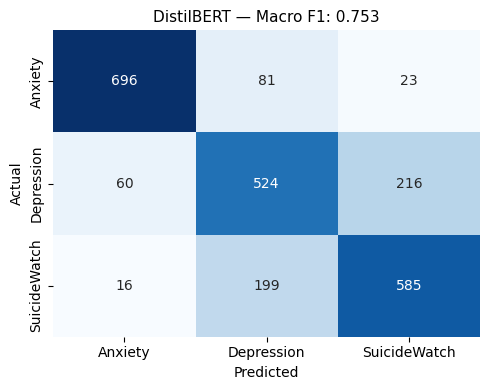

Saved confusion_distilbert.png


In [9]:
cm = confusion_matrix(test_labels, test_preds, labels=CLASSES)

fig, ax = plt.subplots(figsize=(5, 4))
sns.heatmap(
    cm, annot=True, fmt='d', cmap='Blues',
    xticklabels=CLASSES, yticklabels=CLASSES,
    ax=ax, cbar=False
)
ax.set_title(f'DistilBERT — Macro F1: {test_f1:.3f}', fontsize=11)
ax.set_xlabel('Predicted')
ax.set_ylabel('Actual')
plt.tight_layout()
plt.savefig('confusion_distilbert.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved confusion_distilbert.png')

## Cell 10 — Classification report

In [10]:
print(classification_report(test_labels, test_preds, target_names=CLASSES))

              precision    recall  f1-score   support

     Anxiety       0.90      0.87      0.89       800
  Depression       0.65      0.66      0.65       800
SuicideWatch       0.71      0.73      0.72       800

    accuracy                           0.75      2400
   macro avg       0.75      0.75      0.75      2400
weighted avg       0.75      0.75      0.75      2400



## Cell 11 — Save results for final comparison

In [11]:
results = pd.DataFrame([{
    'Model':         'DistilBERT (improved)',
    'CV Macro F1':   round(np.mean(cv_f1),  4),
    'CV Std':        round(np.std(cv_f1),   4),
    'Test Macro F1': round(test_f1,         4),
    'Test Acc':      round(test_acc,        4),
    'AUC-ROC':       round(test_auc,        4)
}])

results.to_csv('distilbert_results.csv', index=False)
print('Saved distilbert_results.csv')

try:
    classical = pd.read_csv('classical_results.csv')
    all_results = pd.concat([classical, results], ignore_index=True)
    all_results = all_results.sort_values('Test Macro F1', ascending=False)
    all_results.to_csv('all_results.csv', index=False)
    print('\nSaved all_results.csv (classical + DistilBERT)')
    print('\n===== Final Leaderboard =====')
    print(all_results.to_string(index=False))
except FileNotFoundError:
    print('classical_results.csv not found — copy it here to merge results')
    print('\nDistilBERT result:')
    print(results.to_string(index=False))

Saved distilbert_results.csv
classical_results.csv not found — copy it here to merge results

DistilBERT result:
                Model  CV Macro F1  CV Std  Test Macro F1  Test Acc  AUC-ROC
DistilBERT (improved)       0.7462  0.0031         0.7531    0.7521   0.9043
